# Data Mining_2_Module_3
## 02 — Motifs and Discords

- signal: **unscaled `enmo`**;
- algorithm: Matrix Profile with **STOMP**;
- time resolution: 30 minutes per observation;
- windows:
  - `w=6` → 3 hours;
  - `w=12` → 6 hours;
- up to 3 motif groups per series;
- up to 3 non-overlapping discords per series;
- constant/invalid subsequences are excluded.

In [1]:
from pathlib import Path
import warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

PROJECT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/progetto dm2"),
]

def is_project_dir(path):
    return path.exists() and (
        (path / "data").exists()
        or (path / "artifacts").exists()
        or any(path.glob("CMI_timeseries_dataset*.pkl"))
    )

PROJECT_DIR = next((p for p in PROJECT_CANDIDATES if is_project_dir(p)), None)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Project folder not found. Update PROJECT_CANDIDATES with your local project path."
    )

TS_PROCESSED_DIR = PROJECT_DIR / "data" / "processed" / "timeseries"
MODULE3_DIR = PROJECT_DIR / "artifacts" / "module3"

TS_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODULE3_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed time-series directory:", TS_PROCESSED_DIR)
print("Module 3 artifacts:", MODULE3_DIR)

Project directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2
Processed time-series directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/timeseries
Module 3 artifacts: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module3


In [2]:
INPUT_PATH = TS_PROCESSED_DIR / "CMI_timeseries_dataset_preproc.pkl"
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        "Run 01_TimeSeries_Preparation first. Missing: " + str(INPUT_PATH)
    )

ts_preproc = pd.read_pickle(INPUT_PATH)
print("Loaded:", INPUT_PATH)
print("Time series:", len(ts_preproc))
print("First shape:", ts_preproc[0].shape)

MOTIF_DIR = MODULE3_DIR / "motifs_discords"
MOTIF_DIR.mkdir(parents=True, exist_ok=True)

Loaded: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/timeseries/CMI_timeseries_dataset_preproc.pkl
Time series: 4258
First shape: (200, 13)


## 1. Dependency check

If the import below fails, install `matrixprofile-ts` in the active environment and restart the kernel.

In [4]:
%pip install matrixprofile-ts


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
try:
    from matrixprofile import matrixProfile
    from matrixprofile import motifs
    from matrixprofile.discords import discords
except ImportError as exc:
    raise ImportError(
        "Missing matrixprofile-ts. Install it in this kernel/environment, then restart."
    ) from exc

from numpy.lib.stride_tricks import sliding_window_view

print("matrixprofile-ts imported successfully.")

matrixprofile-ts imported successfully.


## 2. Final multiscale configuration

In [6]:
OBS_DURATION_MINUTES = 30
OBS_DURATION_HOURS = 0.5
window_sizes = [6, 12]
max_motifs = 3
k_discords = 3
STD_TOLERANCE = 1e-10

window_config_df = pd.DataFrame({
    "w": window_sizes,
    "duration_hours": [w * OBS_DURATION_HOURS for w in window_sizes],
    "interpretation": ["short local activity pattern", "six-hour local pattern"],
})
display(window_config_df)

,w,duration_hours,interpretation
0,6,3.0,short local activity pattern
1,12,6.0,six-hour local pattern


## 3. Matrix Profile helper functions

In [7]:
def clean_values(x):
    """
    Sostituisce eventuali NaN o infiniti con la mediana
    dei valori finiti della stessa time series.
    """

    x = np.asarray(x, dtype=float).copy()

    finite_mask = np.isfinite(x)

    if finite_mask.sum() == 0:
        raise ValueError(
            "La serie non contiene alcun valore finito."
        )

    median_value = np.median(x[finite_mask])

    x[~finite_mask] = median_value

    return x

def prepare_matrix_profile(
    x,
    mp,
    mpi,
    w,
    std_tolerance=1e-10
):
    """
    Identifica le sottosequenze costanti o numericamente
    quasi costanti e impedisce che vengano selezionate
    come motifs o discords.

    Restituisce tre versioni della Matrix Profile:

    - mp_for_motifs:
      valori non validi impostati a +inf, perché i motifs
      vengono individuati cercando i minimi;

    - mp_for_discords:
      valori non validi impostati a -inf, perché i discords
      vengono individuati cercando i massimi;

    - mp_for_plot:
      valori non validi impostati a NaN per non disegnarli.
    """

    x = np.asarray(x, dtype=float)
    mp = np.asarray(mp, dtype=float)
    mpi = np.asarray(mpi, dtype=float)

    windows = sliding_window_view(
        x,
        window_shape=w
    )

    window_std = np.std(
        windows,
        axis=1
    )

    constant_mask = (
        ~np.isfinite(window_std)
        | (window_std <= std_tolerance)
    )

    # Verifica della validità degli indici del nearest neighbour
    mpi_valid = np.isfinite(mpi)

    mpi_indices = np.full(
        shape=len(mpi),
        fill_value=-1,
        dtype=int
    )

    mpi_indices[mpi_valid] = mpi[mpi_valid].astype(int)

    mpi_in_range = (
        (mpi_indices >= 0)
        & (mpi_indices < len(constant_mask))
    )

    neighbour_constant_mask = np.zeros(
        len(mp),
        dtype=bool
    )

    neighbour_constant_mask[mpi_in_range] = (
        constant_mask[
            mpi_indices[mpi_in_range]
        ]
    )

    invalid_mask = (
        constant_mask
        | ~np.isfinite(mp)
        | ~mpi_in_range
        | neighbour_constant_mask
    )

    mp_for_motifs = mp.copy()
    mp_for_motifs[invalid_mask] = np.inf

    mp_for_discords = mp.copy()
    mp_for_discords[invalid_mask] = -np.inf

    mp_for_plot = mp.copy()
    mp_for_plot[invalid_mask] = np.nan

    return {
        "mp_for_motifs": mp_for_motifs,
        "mp_for_discords": mp_for_discords,
        "mp_for_plot": mp_for_plot,
        "invalid_mask": invalid_mask,
        "constant_mask": constant_mask,
        "window_std": window_std
    }

def filter_motif_groups(
    motif_groups,
    motif_distances,
    invalid_mask,
    series_length,
    w
):
    """
    Elimina da ciascun gruppo motif eventuali posizioni
    non valide, costanti o esterne ai limiti della serie.
    Mantiene soltanto gruppi con almeno due occorrenze.
    """

    filtered_groups = []
    filtered_distances = []

    for group_index, group in enumerate(motif_groups):

        valid_group = []

        for start in np.asarray(group).ravel():

            if not np.isfinite(start):
                continue

            start = int(start)

            if start < 0:
                continue

            if start >= len(invalid_mask):
                continue

            if start + w > series_length:
                continue

            if invalid_mask[start]:
                continue

            valid_group.append(start)

        valid_group = sorted(set(valid_group))

        if len(valid_group) < 2:
            continue

        filtered_groups.append(valid_group)

        if group_index < len(motif_distances):
            filtered_distances.append(
                motif_distances[group_index]
            )
        else:
            filtered_distances.append(np.nan)

    return filtered_groups, filtered_distances

def filter_discord_indices(
    discord_indices,
    invalid_mask,
    series_length,
    w,
    k
):
    """
    Mantiene soltanto discords validi e non sovrapposti.
    """

    valid_discords = []

    for start in np.asarray(discord_indices).ravel():

        if not np.isfinite(start):
            continue

        start = int(start)

        if start < 0:
            continue

        if start >= len(invalid_mask):
            continue

        if start + w > series_length:
            continue

        if invalid_mask[start]:
            continue

        # Controllo esplicito di non sovrapposizione
        overlaps_previous = any(
            abs(start - previous_start) < w
            for previous_start in valid_discords
        )

        if overlaps_previous:
            continue

        valid_discords.append(start)

        if len(valid_discords) >= k:
            break

    return valid_discords

## 4. Run STOMP on every cleaned time series

This is the computationally expensive transformation.  
The notebook genuinely executes it on first run and materializes the results. On later runs, set `USE_CACHE=True` to reload the exact saved outputs instead of recomputing thousands of Matrix Profiles.

In [8]:
CACHE_FILES = {
    "motif_groups_df": MOTIF_DIR / "motif_groups_df.pkl",
    "motif_occurrences_df": MOTIF_DIR / "motif_occurrences_df.pkl",
    "discords_df": MOTIF_DIR / "discords_df.pkl",
    "mp_summary_df": MOTIF_DIR / "mp_summary_df.pkl",
    "processing_summary_df": MOTIF_DIR / "processing_summary_df.pkl",
}

USE_CACHE = True
cache_ready = all(path.exists() for path in CACHE_FILES.values())

print("Cache ready:", cache_ready)
print("USE_CACHE:", USE_CACHE)

Cache ready: False
USE_CACHE: True


In [9]:
def get_id_target(ts_df, ts_index):
    subject_id = ts_df["id"].iloc[0] if "id" in ts_df.columns else ts_index
    target = ts_df["sii_binary"].iloc[0] if "sii_binary" in ts_df.columns else np.nan
    return subject_id, target

def extract_subsequence_statistics(x, start, w):
    s = x[start:start+w]
    return {
        "mean": float(np.mean(s)),
        "std": float(np.std(s)),
        "min": float(np.min(s)),
        "max": float(np.max(s)),
        "range": float(np.max(s)-np.min(s)),
    }

if USE_CACHE and cache_ready:
    motif_groups_df = pd.read_pickle(CACHE_FILES["motif_groups_df"])
    motif_occurrences_df = pd.read_pickle(CACHE_FILES["motif_occurrences_df"])
    discords_df = pd.read_pickle(CACHE_FILES["discords_df"])
    mp_summary_df = pd.read_pickle(CACHE_FILES["mp_summary_df"])
    processing_summary_df = pd.read_pickle(CACHE_FILES["processing_summary_df"])
    print("Loaded cached Matrix Profile outputs.")

else:
    motif_group_records = []
    motif_occurrence_records = []
    discord_records = []
    mp_summary_records = []
    processing_records = []

    for ts_index, ts_df in enumerate(ts_preproc):
        if ts_index % 250 == 0:
            print(f"Processing time series {ts_index}/{len(ts_preproc)}")

        try:
            x = clean_values(ts_df["enmo"].to_numpy())
        except Exception as error:
            for w in window_sizes:
                processing_records.append(
                    {"ts_index":ts_index,"w":w,"status":"failed","reason":str(error)}
                )
            continue

        subject_id, target = get_id_target(ts_df, ts_index)

        for w in window_sizes:
            duration_hours = w * OBS_DURATION_HOURS

            try:
                with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
                    mp, mpi = matrixProfile.stomp(x, w)

                mp = np.asarray(mp, dtype=float)
                mpi = np.asarray(mpi, dtype=float)

                prepared = prepare_matrix_profile(
                    x=x, mp=mp, mpi=mpi, w=w, std_tolerance=STD_TOLERANCE
                )

                invalid_mask = prepared["invalid_mask"]
                constant_mask = prepared["constant_mask"]
                valid_mask = ~invalid_mask
                valid_mp = mp[valid_mask]

                if len(valid_mp) < 2:
                    processing_records.append({
                        "ts_index":ts_index,"w":w,"status":"skipped",
                        "reason":"fewer than two valid subsequences"
                    })
                    continue

                mp_summary_records.append({
                    "ts_index":ts_index, "id":subject_id, "target":target,
                    "w":w, "duration_hours":duration_hours,
                    "n_total_windows":int(len(mp)),
                    "n_constant_windows":int(constant_mask.sum()),
                    "n_invalid_windows":int(invalid_mask.sum()),
                    "n_valid_windows":int(valid_mask.sum()),
                    "mp_min":float(np.min(valid_mp)),
                    "mp_mean":float(np.mean(valid_mp)),
                    "mp_median":float(np.median(valid_mp)),
                    "mp_max":float(np.max(valid_mp)),
                    "mp_std":float(np.std(valid_mp)),
                })

                try:
                    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
                        raw_groups, raw_dist = motifs.motifs(
                            x,
                            (prepared["mp_for_motifs"], mpi),
                            max_motifs=max_motifs,
                            ex_zone=w//2,
                        )
                    groups, distances = filter_motif_groups(
                        raw_groups, raw_dist, invalid_mask, len(x), w
                    )
                except Exception:
                    groups, distances = [], []

                for rank, group in enumerate(groups[:max_motifs], start=1):
                    try:
                        distance = float(np.asarray(distances[rank-1]).ravel()[0])
                    except Exception:
                        distance = np.nan

                    motif_group_records.append({
                        "ts_index":ts_index,"id":subject_id,"target":target,
                        "w":w,"duration_hours":duration_hours,
                        "motif_rank":rank,"motif_distance":distance,
                        "n_occurrences":len(group),"motif_starts":tuple(group),
                    })

                    for occurrence_rank, start in enumerate(group, start=1):
                        stats = extract_subsequence_statistics(x, start, w)
                        motif_occurrence_records.append({
                            "ts_index":ts_index,"id":subject_id,"target":target,
                            "w":w,"duration_hours":duration_hours,
                            "motif_rank":rank,"occurrence_rank":occurrence_rank,
                            "motif_start":start,"motif_end":start+w,
                            "motif_distance":distance,
                            "motif_mean":stats["mean"],"motif_std":stats["std"],
                            "motif_min":stats["min"],"motif_max":stats["max"],
                            "motif_range":stats["range"],
                        })

                try:
                    raw_discords = discords(
                        prepared["mp_for_discords"], ex_zone=w, k=k_discords
                    )
                    valid_discords = filter_discord_indices(
                        raw_discords, invalid_mask, len(x), w, k_discords
                    )
                except Exception:
                    valid_discords = []

                for rank, start in enumerate(valid_discords, start=1):
                    if not np.isfinite(mp[start]):
                        continue
                    stats = extract_subsequence_statistics(x, start, w)
                    discord_records.append({
                        "ts_index":ts_index,"id":subject_id,"target":target,
                        "w":w,"duration_hours":duration_hours,
                        "discord_rank":rank,"discord_start":start,
                        "discord_end":start+w,"discord_score":float(mp[start]),
                        "discord_mean":stats["mean"],"discord_std":stats["std"],
                        "discord_min":stats["min"],"discord_max":stats["max"],
                        "discord_range":stats["range"],
                    })

                processing_records.append(
                    {"ts_index":ts_index,"w":w,"status":"success","reason":""}
                )

            except Exception as error:
                processing_records.append({
                    "ts_index":ts_index,"w":w,"status":"failed","reason":str(error)
                })

    motif_groups_df = pd.DataFrame(motif_group_records)
    motif_occurrences_df = pd.DataFrame(motif_occurrence_records)
    discords_df = pd.DataFrame(discord_records)
    mp_summary_df = pd.DataFrame(mp_summary_records)
    processing_summary_df = pd.DataFrame(processing_records)

    for name, path in CACHE_FILES.items():
        globals()[name].to_pickle(path)

    print("Matrix Profile outputs computed and cached.")

Processing time series 0/4258
Processing time series 250/4258
Processing time series 500/4258
Processing time series 750/4258
Processing time series 1000/4258
Processing time series 1250/4258
Processing time series 1500/4258
Processing time series 1750/4258
Processing time series 2000/4258
Processing time series 2250/4258
Processing time series 2500/4258
Processing time series 2750/4258
Processing time series 3000/4258
Processing time series 3250/4258
Processing time series 3500/4258
Processing time series 3750/4258
Processing time series 4000/4258
Processing time series 4250/4258
Matrix Profile outputs computed and cached.


## 5. Global strongest motifs and discords

In [11]:
top10_motifs = (
    motif_groups_df.dropna(subset=["motif_distance"])
    .sort_values(["w","motif_distance"], ascending=[True,True])
    .groupby("w", group_keys=False).head(10).reset_index(drop=True)
)

top10_discords = (
    discords_df.dropna(subset=["discord_score"])
    .sort_values(["w","discord_score"], ascending=[True,False])
    .groupby("w", group_keys=False).head(10).reset_index(drop=True)
)

display(top10_motifs)
display(top10_discords)

top10_motifs.to_csv(MOTIF_DIR / "top10_motifs.csv", index=False)
top10_discords.to_csv(MOTIF_DIR / "top10_discords.csv", index=False)
mp_by_target_df.to_csv(MOTIF_DIR / "matrix_profile_by_target.csv", index=False)

print("Top-10 and summary CSVs saved.")

,ts_index,id,target,w,duration_hours,motif_rank,motif_distance,n_occurrences,motif_starts
0,1229,1102,0,6,3.0,1,2.220446e-16,2,"(17, 55)"
1,3513,1475,0,6,3.0,1,2.220446e-16,2,"(8, 22)"
2,3586,1200,0,6,3.0,1,1.168499e-04,2,"(38, 64)"
3,759,937,0,6,3.0,1,3.394204e-04,2,"(14, 48)"
4,3976,1193,0,6,3.0,1,4.739771e-04,2,"(34, 65)"
5,555,2495,0,6,3.0,1,7.735248e-04,2,"(2, 81)"
6,3676,3824,0,6,3.0,1,1.274219e-03,2,"(8, 72)"
7,3676,3824,0,6,3.0,2,2.843333e-03,2,"(23, 54)"
8,2869,2793,1,6,3.0,1,3.239193e-03,2,"(14, 127)"
9,1192,3629,0,6,3.0,1,4.176573e-03,2,"(37, 64)"


,ts_index,id,target,w,duration_hours,discord_rank,discord_start,discord_end,discord_score,discord_mean,discord_std,discord_min,discord_max,discord_range
0,2933,130,0,6,3.0,1,154,160,2.231011,0.097616,0.049690,0.017820,0.144321,0.126501
1,2773,1777,1,6,3.0,1,181,187,2.193426,0.038901,0.009541,0.024873,0.048758,0.023885
2,725,1935,0,6,3.0,1,172,178,2.186666,0.006983,0.002842,0.000837,0.009029,0.008192
3,3501,1328,0,6,3.0,1,104,110,2.154108,0.129208,0.062209,0.022120,0.194846,0.172726
4,1983,3556,1,6,3.0,1,106,112,2.146949,0.605710,0.113748,0.402789,0.725665,0.322876
5,1043,276,0,6,3.0,1,8,14,2.136848,0.014198,0.007267,0.001085,0.021720,0.020635
6,1362,642,0,6,3.0,1,5,11,2.131597,0.025823,0.014281,0.001265,0.040082,0.038817
7,4171,2276,0,6,3.0,1,117,123,2.127986,0.084713,0.017497,0.053315,0.102363,0.049048
8,2805,3919,0,6,3.0,1,118,124,2.127680,0.062948,0.012768,0.036916,0.077228,0.040311
9,487,1339,1,6,3.0,1,109,115,2.107400,0.029578,0.006926,0.016436,0.036552,0.020116


Top-10 and summary CSVs saved.


## 6. Representative final visualizations

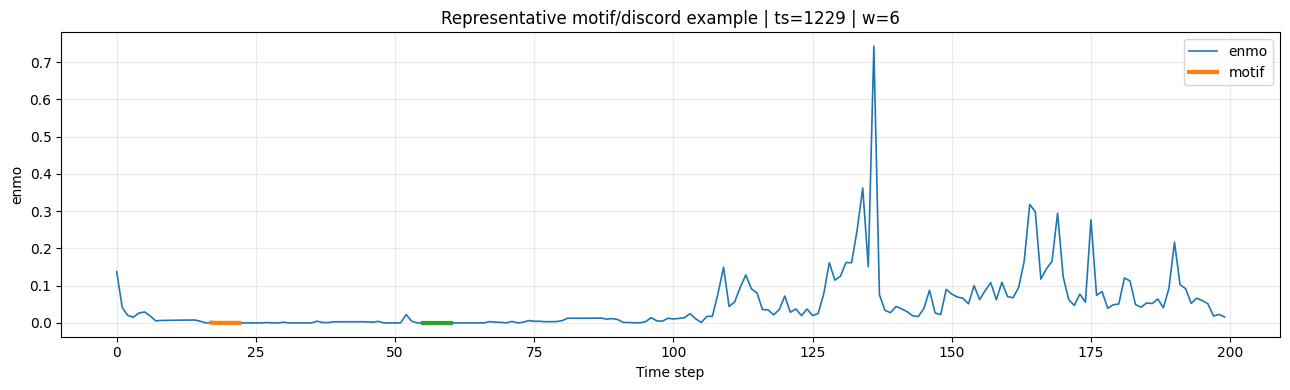

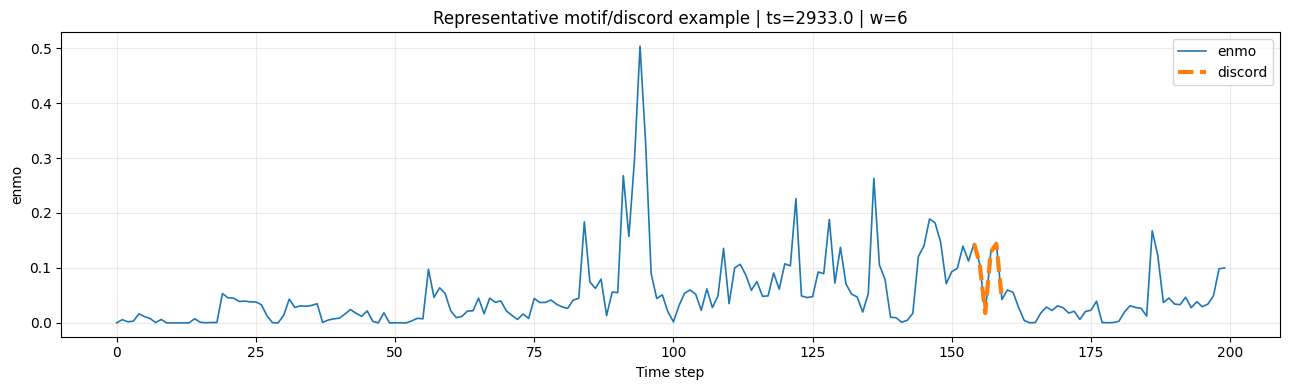

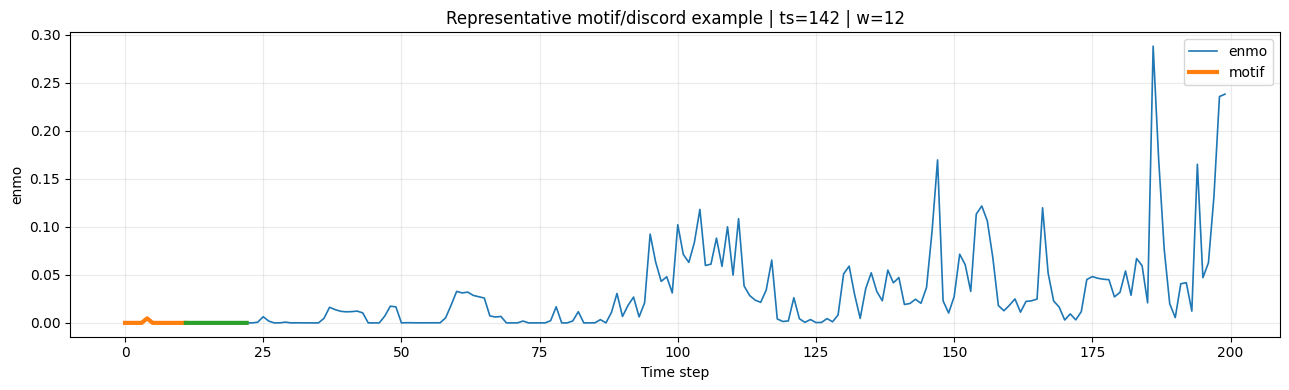

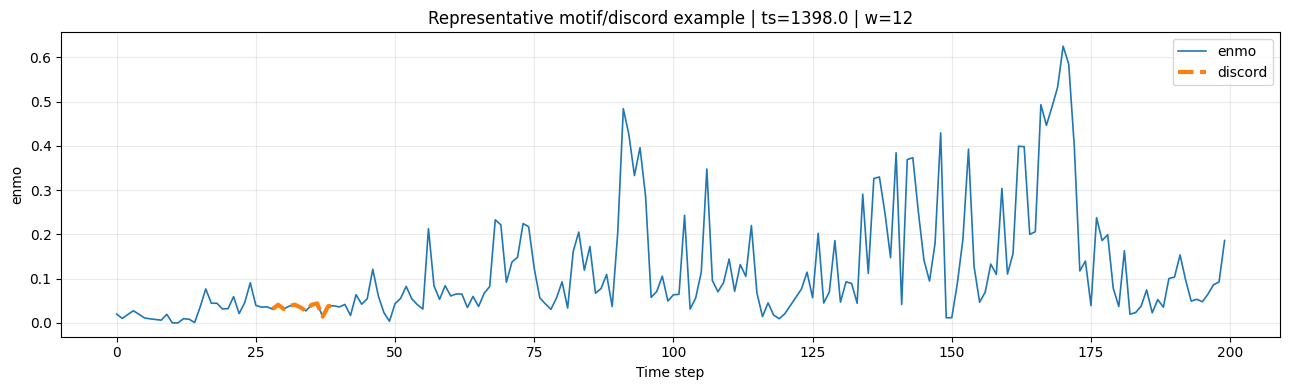

In [12]:
def plot_pattern_example(ts_index, w, motif_starts=None, discord_starts=None):
    x = ts_preproc[int(ts_index)]["enmo"].to_numpy(dtype=float)
    plt.figure(figsize=(13,4))
    plt.plot(x, linewidth=1.2, label="enmo")

    for j,start in enumerate(motif_starts or []):
        start = int(start)
        plt.plot(range(start,start+w), x[start:start+w], linewidth=3,
                 label="motif" if j == 0 else None)

    for j,start in enumerate(discord_starts or []):
        start = int(start)
        plt.plot(range(start,start+w), x[start:start+w], linewidth=3,
                 linestyle="--", label="discord" if j == 0 else None)

    plt.title(f"Representative motif/discord example | ts={ts_index} | w={w}")
    plt.xlabel("Time step")
    plt.ylabel("enmo")
    plt.legend()
    plt.grid(alpha=.25)
    plt.tight_layout()
    plt.show()

for w in window_sizes:
    strongest_motif = top10_motifs[top10_motifs["w"] == w].iloc[0]
    strongest_discord = top10_discords[top10_discords["w"] == w].iloc[0]

    motif_starts = list(strongest_motif["motif_starts"])
    plot_pattern_example(
        strongest_motif["ts_index"], w,
        motif_starts=motif_starts
    )
    plot_pattern_example(
        strongest_discord["ts_index"], w,
        discord_starts=[strongest_discord["discord_start"]]
    )